<a href="https://colab.research.google.com/github/snehalnandi/React-Data-Dashboard/blob/main/01_Intro_to_Pandas_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np

# 1. Creating the raw, "messy" data from the sales team
raw_data = {
    'OrderID': ['ORD-101', 'ORD-102', 'ORD-103', 'ORD-104', 'ORD-105', 'ORD-106', 'ORD-107'],
    'Date': ['2026-06-01', '2026-06-01', '2026-06-02', '2026-06-02', '2026-06-03', '2026-06-03', '2026-06-04'],
    'Product_SKU': ['SKU-JT01', 'SKU-BS02', 'SKU-JT01', 'SKU-ES03', 'SKU-BP05', 'SKU-BS02', 'SKU-EH04'],
    'Quantity': [5, 2, np.nan, 10, 4, 1, 3], # Wait... what is "NaN"?
    'Unit_Price_INR': [800, 450, 800, 1200, 350, 450, 600]
}

# 2. Loading the data into a Pandas DataFrame (our digital spreadsheet)
sales_df = pd.DataFrame(raw_data)

# 3. Display the data so we can see it!
sales_df

,OrderID,Date,Product_SKU,Quantity,Unit_Price_INR
0,ORD-101,2026-06-01,SKU-JT01,5.0,800
1,ORD-102,2026-06-01,SKU-BS02,2.0,450
2,ORD-103,2026-06-02,SKU-JT01,NaN,800
3,ORD-104,2026-06-02,SKU-ES03,10.0,1200
4,ORD-105,2026-06-03,SKU-BP05,4.0,350
5,ORD-106,2026-06-03,SKU-BS02,1.0,450
6,ORD-107,2026-06-04,SKU-EH04,3.0,600


In [17]:
# 1. We use a built-in Pandas command called .dropna()
# This tells the computer: "Look through the data. If any row has a blank (NaN), delete the whole row."

clean_sales_df = sales_df.dropna()

# 2. Display our shiny, new, clean data
clean_sales_df

,OrderID,Date,Product_SKU,Quantity,Unit_Price_INR
0,ORD-101,2026-06-01,SKU-JT01,5.0,800
1,ORD-102,2026-06-01,SKU-BS02,2.0,450
3,ORD-104,2026-06-02,SKU-ES03,10.0,1200
4,ORD-105,2026-06-03,SKU-BP05,4.0,350
5,ORD-106,2026-06-03,SKU-BS02,1.0,450
6,ORD-107,2026-06-04,SKU-EH04,3.0,600


In [18]:
# 1. We create a brand NEW column called 'Total_Price'
# We tell Python to multiply the Quantity column by the Unit Price column for every single row.

# Warning: You might get a red "SettingWithCopyWarning" warning here.
# Don't panic! It's just Python being overly cautious. The code will still work perfectly.
clean_sales_df['Total_Price'] = clean_sales_df['Quantity'] * clean_sales_df['Unit_Price_INR']

# 2. Show the updated spreadsheet
clean_sales_df

/tmp/ipykernel_2813/2834623915.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_sales_df['Total_Price'] = clean_sales_df['Quantity'] * clean_sales_df['Unit_Price_INR']


,OrderID,Date,Product_SKU,Quantity,Unit_Price_INR,Total_Price
0,ORD-101,2026-06-01,SKU-JT01,5.0,800,4000.0
1,ORD-102,2026-06-01,SKU-BS02,2.0,450,900.0
3,ORD-104,2026-06-02,SKU-ES03,10.0,1200,12000.0
4,ORD-105,2026-06-03,SKU-BP05,4.0,350,1400.0
5,ORD-106,2026-06-03,SKU-BS02,1.0,450,450.0
6,ORD-107,2026-06-04,SKU-EH04,3.0,600,1800.0


In [19]:
# We tell the computer:
# 1. Look at the 'clean_sales_df' table.
# 2. Grab ONLY the 'Total_Price' column.
# 3. Add (.sum) all the numbers together.

grand_total = clean_sales_df['Total_Price'].sum()

print("The total revenue is: ₹", grand_total)

The total revenue is: ₹ 20550.0


In [20]:
# 1. We GROUP BY the product SKU.
# 2. We look at the 'Quantity' column.
# 3. We ADD (.sum) them up for each group.
# 4. We SORT the values so the biggest seller is at the top!

top_products = clean_sales_df.groupby('Product_SKU')['Quantity'].sum().sort_values(ascending=False)
print("Total Items Sold by Product:")
print(top_products)

Total Items Sold by Product:
Product_SKU
SKU-ES03    10.0
SKU-JT01     5.0
SKU-BP05     4.0
SKU-EH04     3.0
SKU-BS02     3.0
Name: Quantity, dtype: float64


In [21]:
# Fill in the blanks!
daily_revenue = clean_sales_df.groupby('Date')['Total_Price'].sum()

print(daily_revenue)



Date
2026-06-01     4900.0
2026-06-02    12000.0
2026-06-03     1850.0
2026-06-04     1800.0
Name: Total_Price, dtype: float64


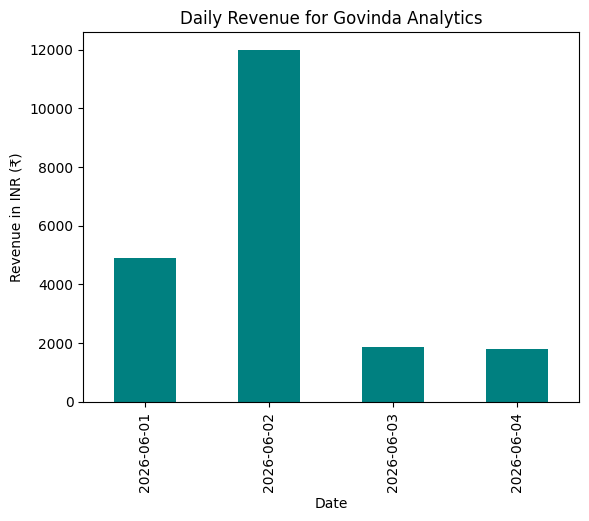

In [22]:
# 1. We import a plotting library and give it a nickname 'plt'
import matplotlib.pyplot as plt

# 2. We take the 'daily_revenue' you just created, and tell it to plot a bar chart.
daily_revenue.plot(kind='bar', color='teal', title='Daily Revenue for Govinda Analytics')

# 3. We label the side axis so people know it's money.
plt.ylabel('Revenue in INR (₹)')

# 4. Show the picture!
plt.show()